# Notebook for preprocessing EDGAR8 for use as anthropogenic prior

* select years
* cut domain
* sum sector-specific gridded fluxes together 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import re


In [2]:
DATA_PATH1 = "/home/pietaril/Documents/data/EDGAR8_CO2/bio_EDGAR/"
DATA_PATH2 = "/home/pietaril/Documents/data/EDGAR8_CO2/IEA_EDGAR/"
OUT_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/"



def get_filenames(dirpaths):
    filenames = []
    for dirpath in dirpaths:
        for subdir in os.listdir(dirpath):
            subdirpath = os.path.join(dirpath, subdir)
            filenames +=  [os.path.join(subdirpath,f) for f in os.listdir(subdirpath) if f.endswith(".nc")]
    return filenames


def extract_year(filename):
    #Extract year from filename
    year = int(re.findall(r'\d{4}', filename)[-1])
    return year

def select_area(aoi, ds):
    # Select the area based on area of interest
    
    area_subset = ds.sel(lon=slice(aoi[0], aoi[1]),
                    lat=slice(aoi[2], aoi[3]))
    return area_subset





def sum_sectors(aoi, input_files, output_file):
    """
    Sums the fluxes from multiple NetCDF files corresponding to the different sectors
    of EDGAR, converts them from kg/m2/s to kg/m2/hr and writes the result to a new NetCDF file.

    Parameters:
    - input_files (list of str): List of paths to input NetCDF files.
    - output_file (str): Path to the output NetCDF file.
    """
 

    # Open all input files
    datasets = [xr.open_dataset(file) for file in input_files]
    

    #pick area
    subsets = [select_area(aoi, ds) for ds in datasets]

    #convert to double precision

    subsets64 = [ds.assign({"fluxes": ds["fluxes"].astype('float64')}) 
                 for ds in subsets
]


    # Compute the sum of fluxes across all datasets

    flux_sum = sum(ds for ds in subsets64)

    #convert from kg/m2/s to kg/m2/hr
    flux_sum["fluxes"] = flux_sum["fluxes"]*60*60

    #rename variables to match CIF standard
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        "fluxes": "emi_anth"
    }
    flux_sum = flux_sum.rename(rename_map)
    

    # Save the result to a new NetCDF file
    
    flux_sum.attrs.update({"description": "Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes from all sectors",
                            "units": "kg m-2 hr-1"})



    # Write the output dataset to a new NetCDF file
    flux_sum.to_netcdf(output_file, encoding={'time':{'units': "days since 1900-01-01"}})

    # Close all datasets
    for ds in datasets:
        ds.close()

    print(f"Sum of fluxes saved to file {output_file}")
    
    






# Examine the structure of the original EDGAR 2024 datasets

In [3]:
fnames = get_filenames([DATA_PATH1, DATA_PATH2])
ds = xr.open_dataset(fnames[0], )
ds

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2015-01-15 2015-02-15 ... 2015-12-15
Data variables:
    fluxes   (time, lat, lon) float32 ...
Attributes:
    description:       Industrial processes
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ghg2024
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ghg2024#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ghg2024#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ghg2024#info JR...
    units:             kg m-2 s-1

In [4]:
ds = ds.sortby("time")
ds

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2015-01-15 2015-02-15 ... 2015-12-15
Data variables:
    fluxes   (time, lat, lon) float32 ...
Attributes:
    description:       Industrial processes
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ghg2024
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ghg2024#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ghg2024#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ghg2024#info JR...
    units:             kg m-2 s-1

# Sum the gridded fluxes of different sectors together and save

In [19]:



aoi = [-15, 40, 34, 73]

fnames = get_filenames([DATA_PATH1, DATA_PATH2])


# create DataFrame with filenames and years to later group by year
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('year').reset_index(drop=True)

for year in range(2008,2024):
    files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(files_1year)==16
    output_file = f"{OUT_PATH}EDGAR8_CO2_monthly_flux_summed_sectors_{year}.nc"
    ds = sum_sectors(aoi, files_1year, output_file)
    


Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2008.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2009.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2010.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2011.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2012.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2013.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2014.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors

In [9]:
ds

<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 12)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2008-01-15 2008-02-15 ... 2008-12-15
Data variables:
    fluxes     (time, latitude, longitude) float32 2.036e-10 ... 2.111e-11
Attributes:
    description:  Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes across all...
    units:        kg m-2 s-1

# Check the created files

In [3]:
sum_files = os.listdir(OUT_PATH)
print(sum_files)
sum_sectors = xr.open_dataset(OUT_PATH+sum_files[5])
sum_sectors

['EDGAR8_CO2_monthly_flux_summed_sectors_2016.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2017.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2015.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2009.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2021.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2020.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2012.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2022.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2014.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2011.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2023.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2013.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2008.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2019.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2018.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2010.nc']


<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 12)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2020-01-15 2020-02-15 ... 2020-12-15
Data variables:
    emi_anth   (time, latitude, longitude) float64 ...
Attributes:
    description:  Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes from all s...
    units:        kg m-2 hr-1

In [ ]:
#rename files
# fnames = os.listdir(OUT_PATH)
# for fname in fnames:
#     year = extract_year(fname)
#     newname = f"EDGAR8_CO2_monthly_flux_summed_sectors_{year}.nc"
#     os.rename(os.path.join(OUT_PATH, fname), os.path.join(OUT_PATH, newname))

In [4]:
import netCDF4 as nc
print(sum_files[0])
data_nc = nc.Dataset(OUT_PATH+sum_files[0], 'r')
data_nc.variables

EDGAR8_CO2_monthly_flux_summed_sectors_2016.nc


{'latitude': <class 'netCDF4._netCDF4.Variable'>
 float64 latitude(latitude)
     _FillValue: nan
     units: degrees_north
     standard_name: latitude
     long_name: latitude
 unlimited dimensions: 
 current shape = (390,)
 filling on,
 'longitude': <class 'netCDF4._netCDF4.Variable'>
 float64 longitude(longitude)
     _FillValue: nan
     units: degrees_east
     standard_name: longitude
     long_name: longitude
 unlimited dimensions: 
 current shape = (550,)
 filling on,
 'time': <class 'netCDF4._netCDF4.Variable'>
 int64 time(time)
     long_name: time
     standard_name: time
     units: days since 1900-01-01
     calendar: proleptic_gregorian
 unlimited dimensions: 
 current shape = (12,)
 filling on, default _FillValue of -9223372036854775806 used,
 'emi_anth': <class 'netCDF4._netCDF4.Variable'>
 float64 emi_anth(time, latitude, longitude)
     _FillValue: nan
 unlimited dimensions: 
 current shape = (12, 390, 550)
 filling on}

# Rename variables in the already processed files

In [10]:
def rename_variables_in_netcdf(input_dir, output_dir, rename_map):
    """
    Reads NetCDF files from a directory, renames specified variables, and writes the changes to new files.

    Parameters:
        input_dir (str): Directory containing input NetCDF files.
        output_dir (str): Directory to save the modified NetCDF files.
        rename_map (dict): Mapping of old variable names to new variable names (e.g., {'old_var': 'new_var'}).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for filename in os.listdir(input_dir):
        if filename.endswith(".nc"):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            try:
                # Open the NetCDF file
                ds = xr.open_dataset(input_path)

                # Rename variables
                ds = ds.rename(rename_map)

                # Write the modified dataset to a new file
                ds.to_netcdf(output_path)

                print(f"Processed file: {filename}")

            except Exception as e:
                print(f"Error processing file {filename}: {e}")

# Define input directory, output directory, and rename mapping
input_directory =  "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums_old/"
output_directory = "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/"
variable_rename_map = {
    "lat": "latitude",
    "lon": "longitude"
}

rename_variables_in_netcdf(input_directory, output_directory, variable_rename_map)




Processed file: EDGAR8_CO2_monthly_flux_sums_2017.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2016.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2021.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2011.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2010.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2019.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2015.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2009.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2020.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2022.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2012.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2014.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2018.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2008.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2013.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2023.nc


# Plot the preprocessed fluxes

In [5]:
#from datetime import datetime
data = sum_sectors["fluxes"]
str(data.time.values[0])[0:7]


'2017-01'

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


def plot_fluxmaps(sum_sectors, figpath=None):
    data = sum_sectors["emi_anth"]
    g = data.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.2,
                     subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "anth CO$_2$ prior flux [$kg$ $m^{-2} hr^{-1}$]", shrink=0.9 ),

    )


    for i, ax in enumerate(g.axes.flat):
        time = str(data.time.values[i])[0:7]
        ax.set_title(time)
        ax.coastlines()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.draw()

    if not figpath==None:
        figname = f"EDGAR8_summed_monthly_CO2_fluxmaps_{time[0:4]}.png"
        plt.savefig(figpath+figname)
        plt.draw()
    



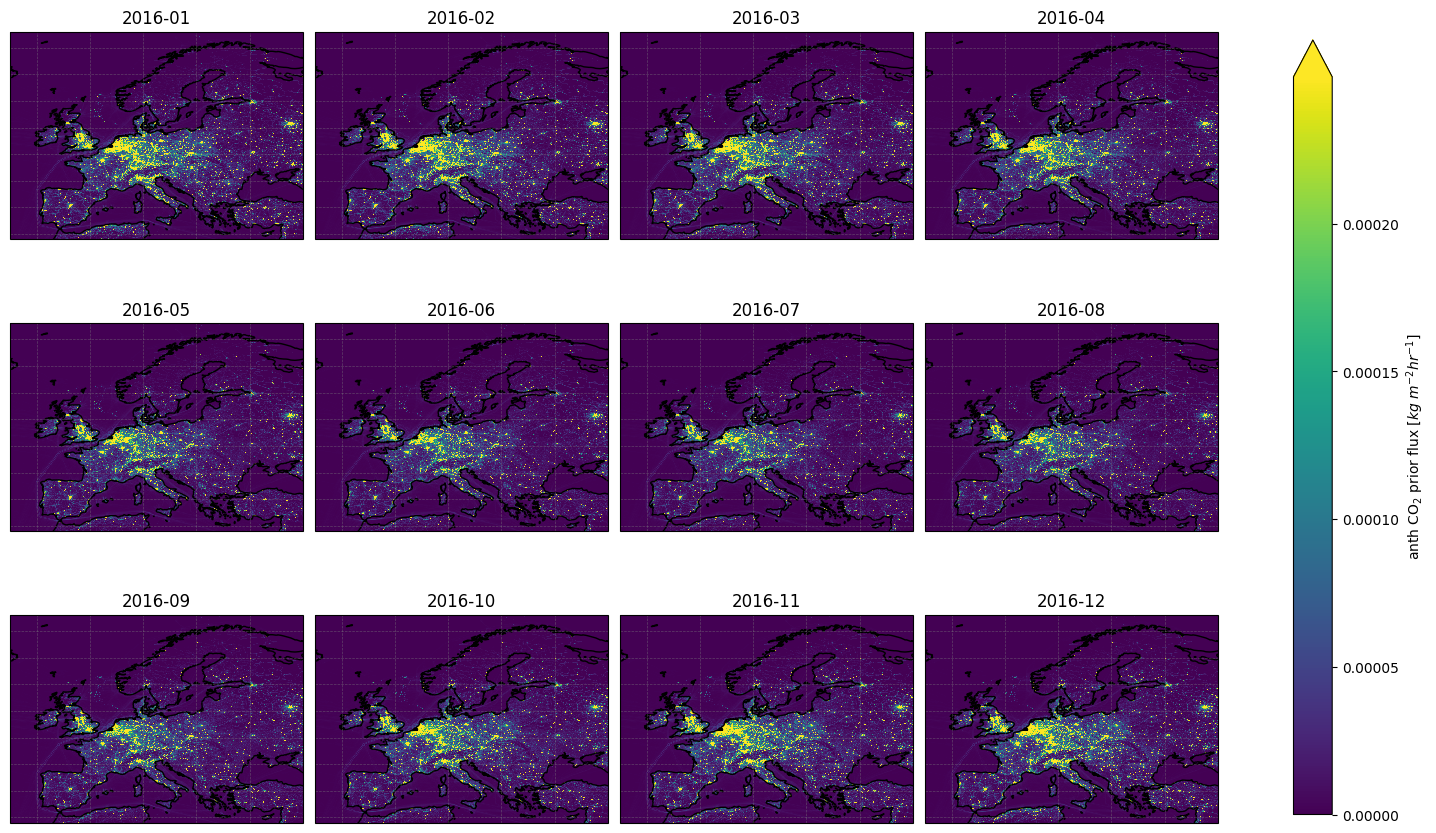

In [10]:

sum_files = os.listdir(OUT_PATH)
for file in sum_files[:1]:
    sum_sectors = xr.open_dataset(OUT_PATH+file)
    plot_fluxmaps(sum_sectors)
    #plot_fluxmaps(sum_sectors, "/home/pietaril/Documents/plots/EDGAR8/summed_gridmaps/")
    sum_sectors.close()


# Compute and plot total emissions (Tg/year)

* Unit conversion from g m-2 s-1 to Tg/year

In [11]:


def hours_in_months(year):
    """
    Calculate the number of hours in each month of a given year,
    taking into account leap years.

    Args:
        year (int): The year to calculate the hours for.

    Returns:
        an array with hours in each month of the year
    """
    import calendar

 
    # Get the number of days in each month of the year. Note that monthrange counts months from 1 to 12, 
    # and takes leap years into account.
    days_in_month = [calendar.monthrange(year, month)[1] for month in range(1, 13)]

    # Calculate hours for each month
    hours_per_month = [days_in_month[i] * 24 for i in range(12)]

    return np.array(hours_per_month)



from areagrid import areagrid



def monthly_fluxes_to_Mt_per_year(fname):
    """Helper function to convert a dataset with a year of monthly EDGAR8 flux gridmaps (with all sectors summed together)
    from g m-2 hr-1 to a single gridmap for the whole year with unit MtCO2/year.
    
    Input: path to sum_sectors dataset created by the sum_sectors function in this Jupyter notebook
    Output:  an Xarray dataset containing a gridmap for the whole year with unit Mt/year."""

    ds = xr.open_dataset(fname)
    #ensure that the time axis in ascending order
    ds = ds.sortby("time")

    lat = ds["latitude"].values
    lon = ds["longitude"].values
    #pick the first time value to be the timestamp representing the whole year
    time = ds["time"].values[0]



    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    #the first dimension here is the month 
    fluxes = ds["emi_anth"]

    # pointwise multiplication by area
    totals = fluxes * grid_of_areas

    # compute  how many seconds per each of the months in the year in question
    year = ds["time"].dt.year.values[0]
    hours_per_month = hours_in_months(year)
    hours_per_month = hours_per_month.reshape((12,1,1))

    #multiply the monthly gridmaps by seconds per month
    totals = hours_per_month *totals

    # kg to megatons
    totals = totals.sum(dim="time") * 1e-9
   
    totals = totals.to_dataset()

    totals.coords["time"] = (time) 
    totals = totals.expand_dims("time")

    #rename fluxes to emissions
    variable_rename_map = {
    "emi_anth":"tot_emi_anth"
    }
    totals = totals.rename(variable_rename_map)
    totals.attrs.update({"description": "Total yearly anthropogenic emissions in Mt/year computed from EDGAR_2024_GHG CO2 monthly fluxes across all sectors",
                           "units": "Mt/year"})

    

    return totals

# Note to self

* I modified the original code so that the total emissions output from monthly_fluxes_to_Mt_per_year is a xarray.Dataset with dimensions (time, latitude, longitude), and time dimension is only of length 1. I checked that the values are the same as with the original function

In [12]:
fnames = [os.path.join(OUT_PATH,file) for file in os.listdir(OUT_PATH)]
f = fnames[0]
print(f)


/home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2016.nc


In [13]:
tot= monthly_fluxes_to_Mt_per_year(f)


tot

<xarray.Dataset>
Dimensions:       (latitude: 390, longitude: 550, time: 1)
Coordinates:
  * latitude      (latitude) float64 34.05 34.15 34.25 ... 72.75 72.85 72.95
  * longitude     (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time          (time) datetime64[ns] 2016-01-15
Data variables:
    tot_emi_anth  (time, latitude, longitude) float64 0.00074 ... 2.939e-05
Attributes:
    description:  Total yearly anthropogenic emissions in Mt/year computed fr...
    units:        Mt/year

2016

In [14]:
# compute and save to file the total emissions

fnames = [os.path.join(OUT_PATH,file) for file in os.listdir(OUT_PATH)]
TOTALS_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_total_emissions_calculated_from_fluxes/"
for f in fnames:
    tot = monthly_fluxes_to_Mt_per_year(f)
    year = extract_year(f)
    tot.to_netcdf(os.path.join(TOTALS_PATH, f"total_emis_from_fluxes_{year}.nc"))


In [15]:
TOTALS_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_total_emissions_calculated_from_fluxes/"
totfiles = [os.path.join(TOTALS_PATH,file) for file in os.listdir(TOTALS_PATH)]
tot = xr.open_dataset(totfiles[0])
print(extract_year(totfiles[0]))
tot


2023


<xarray.Dataset>
Dimensions:       (latitude: 390, longitude: 550, time: 1)
Coordinates:
  * latitude      (latitude) float64 34.05 34.15 34.25 ... 72.75 72.85 72.95
  * longitude     (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time          (time) datetime64[ns] 2023-01-15
Data variables:
    tot_emi_anth  (time, latitude, longitude) float64 ...
Attributes:
    description:  Total yearly anthropogenic emissions in Mt/year computed fr...
    units:        Mt/year

<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 16)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2023-01-15 2019-01-15 ... 2012-01-15
Data variables:
    emissions  (time, latitude, longitude) float64 8.027e-07 ... 2.593e-08
Attributes:
    description:  Total yearly emissions in Tg/year computed from EDGAR_2024_...

Plot the total emissions

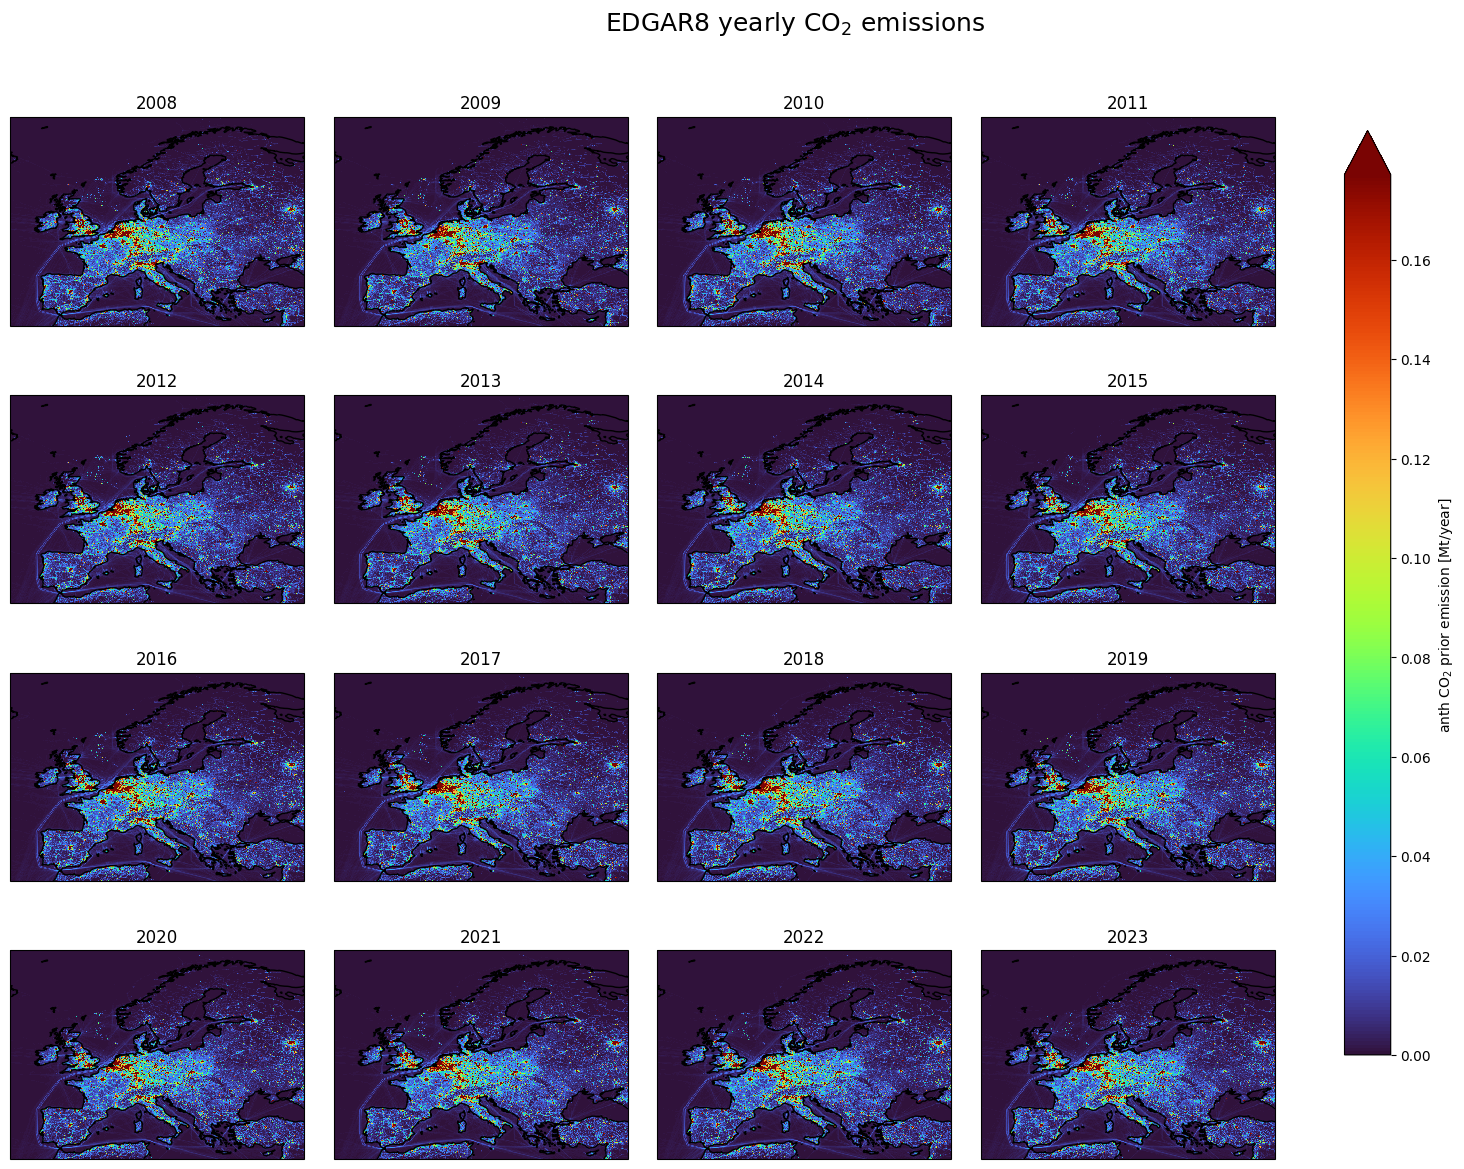

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

totfiles = [os.path.join(TOTALS_PATH,file) for file in os.listdir(TOTALS_PATH)]
datasets = [xr.open_dataset(f) for f in totfiles]


ds = xr.concat(datasets, dim="time") 
ds = ds.sortby("time")




data = ds["tot_emi_anth"]
g = data.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.25, cmap = mpl.colormaps["turbo"],
                    subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "anth CO$_2$ prior emission [Mt/year]", shrink=0.8 ),

)


for i, ax in enumerate(g.axes.flat):
    time = str(data.time.values[i])[0:4]
    ax.set_title(time)
    ax.coastlines()
    #ax.gridlines(draw_labels=False, linewidth=0.5, color='darkgray', alpha=0.5, linestyle='--')

g.fig.suptitle("EDGAR8 yearly CO$_2$ emissions", fontsize=18)
g.fig.subplots_adjust(top=0.9, right=0.8, wspace=0.1, hspace=0.2)

plt.draw()

figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"EDGAR8_yearly_CO2_emissions_from_fluxes.png"
#plt.savefig(figpath+figname)
#plt.draw()

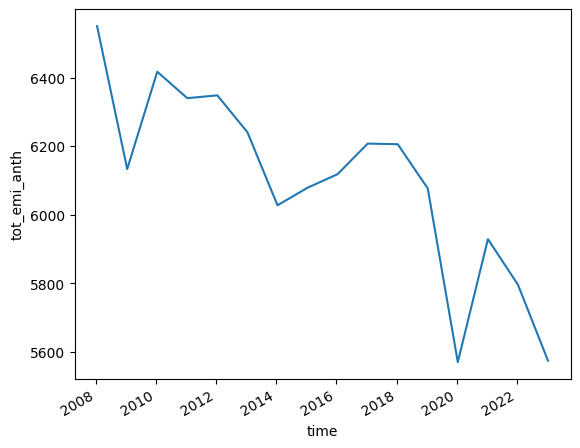

In [17]:
domain_tot = ds.sum(dim=("latitude", "longitude"))
domain_tot["tot_emi_anth"].plot(x="time")


In [36]:
domain_tot


<xarray.Dataset>
Dimensions:    (time: 16)
Coordinates:
  * time       (time) datetime64[ns] 2008-01-15 2009-01-15 ... 2023-01-15
Data variables:
    emissions  (time) float64 6.55 6.134 6.418 6.34 ... 5.57 5.929 5.796 5.575

In [11]:
# old code that I used to compute with wrong units
monthly_totals = pd.DataFrame()
fnames = [OUT_PATH+file for file in sum_files]
for fname in fnames:
    year = extract_year(fname)
    ds = xr.open_dataset(fname)
    data = ds["fluxes"]
    vals = data.sum(dim=["latitude", "longitude"]).values
    monthly_totals[year] = vals
    ds.close()

monthly_totals = monthly_totals.sort_index(axis=1)
#monthly_totals = xr.DataArray(monthly_totals)
monthly_totals


,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,0.003121,0.003105,0.003192,0.003093,0.002996,0.003083,0.002875,0.002895,0.002940,0.003167,0.002994,0.003054,0.002742,0.002928,0.002872,0.002747
1,0.003167,0.003142,0.003214,0.003234,0.003383,0.003192,0.002928,0.003113,0.002838,0.003076,0.003278,0.003022,0.002680,0.002972,0.002875,0.002761
2,0.002867,0.002720,0.002825,0.002908,0.002735,0.002943,0.002612,0.002709,0.002700,0.002624,0.002836,0.002638,0.002487,0.002634,0.002612,0.002512
3,0.002677,0.002341,0.002518,0.002460,0.002549,0.002524,0.002389,0.002434,0.002418,0.002504,0.002402,0.002452,0.002234,0.002453,0.002382,0.002298
4,0.002225,0.002061,0.002248,0.002244,0.002168,0.002166,0.002145,0.002096,0.002070,0.002158,0.002125,0.002195,0.001976,0.002116,0.002016,0.001944
5,0.002158,0.002018,0.002094,0.002095,0.002108,0.002034,0.002035,0.002012,0.001994,0.002028,0.002028,0.001982,0.001819,0.001909,0.001893,0.001828
6,0.002039,0.001891,0.001972,0.002009,0.001983,0.001924,0.001904,0.001927,0.001878,0.001948,0.001923,0.001904,0.001735,0.001817,0.001809,0.001743
7,0.002003,0.001854,0.001925,0.001944,0.001941,0.001891,0.001892,0.001886,0.001872,0.001904,0.001890,0.001849,0.001667,0.001801,0.001750,0.001687
8,0.002338,0.002089,0.002199,0.002130,0.002160,0.002165,0.002125,0.002144,0.002095,0.002154,0.002116,0.002086,0.001879,0.001992,0.002017,0.001944
9,0.002586,0.002448,0.002541,0.002461,0.002464,0.002391,0.002374,0.002460,0.002487,0.002365,0.002376,0.002332,0.002168,0.002292,0.002167,0.002090


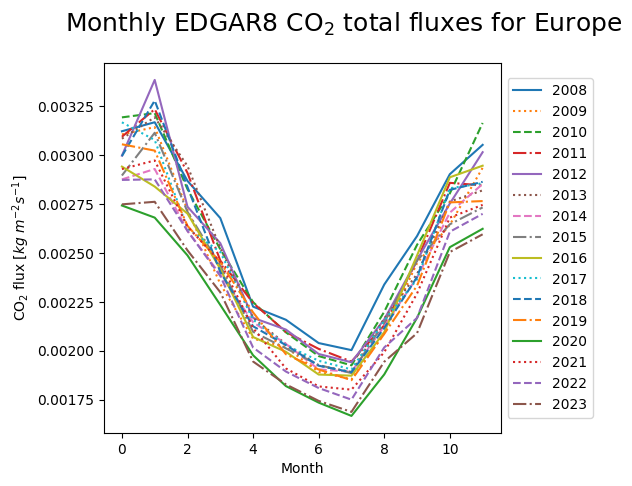

<Figure size 640x480 with 0 Axes>

In [30]:
#pretty plot but the unit doesn't make sense
import matplotlib

linestyles = ["solid", "dotted", "dashed", "dashdot"]
linestyles = linestyles*4

#cmap = matplotlib.colormaps['viridis'].resampled(16).colors
fig, ax = plt.subplots(layout="constrained")
for ind, year in enumerate(monthly_totals.columns):
    ax.plot(monthly_totals[year], label=year, linestyle=linestyles[ind] ) #color=cmap[ind])
ax.set_xlabel("Month")
ax.set_ylabel("CO$_2$ flux [$kg$ $m^{-2} s^{-1}$]")
#Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle(f"Monthly EDGAR8 CO$_2$ total fluxes for Europe", fontsize=18)
plt.show()
plt.savefig("/home/pietaril/Documents/plots/EDGAR8/monthly_totals.png")




# Look at dryrun inputs to infer formatting

* OBS! Xarray seems to automatically display the time as datetime64, but when opening the file with netCDF4 command nc.Dataset(path, 'r'), it displays the actual unit used

In [31]:
TESTPATH = "/home/pietaril/Documents/data/cif_test_inputs/testinput_from_sara/CH4_emisch4_2020_02X02.nc"
ds = xr.open_dataset(TESTPATH)
ds

<xarray.Dataset>
Dimensions:    (time: 12, latitude: 900, longitude: 1800)
Coordinates:
  * time       (time) datetime64[ns] 2020-01-01 2020-02-01 ... 2020-12-01
  * latitude   (latitude) float32 -90.0 -89.8 -89.6 -89.4 ... 89.4 89.6 89.8
  * longitude  (longitude) float32 -180.0 -179.8 -179.6 ... 179.4 179.6 179.8
Data variables:
    emisch4    (time, latitude, longitude) float64 ...
Attributes:
    history:  monthly mean total CH4 emission EDGARv8/GAINS lpx/JSBACH GFED o...
    contact:  anteneh.mengistu@fmi.fi

In [32]:
import netCDF4 as nc
data_nc = nc.Dataset(TESTPATH, 'r')
data_nc.variables

{'time': <class 'netCDF4._netCDF4.Variable'>
 float32 time(time)
     units: days since 1900-01-01
     long_name: output_time
 unlimited dimensions: 
 current shape = (12,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'latitude': <class 'netCDF4._netCDF4.Variable'>
 float32 latitude(latitude)
     units: degrees_north
     long_name: latitude
 unlimited dimensions: 
 current shape = (900,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'longitude': <class 'netCDF4._netCDF4.Variable'>
 float32 longitude(longitude)
     units: degrees_east
     long_name: longitude
 unlimited dimensions: 
 current shape = (1800,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'emisch4': <class 'netCDF4._netCDF4.Variable'>
 float64 emisch4(time, latitude, longitude)
     units: kg(CH4)/m2/hr
 unlimited dimensions: 
 current shape = (12, 900, 1800)
 filling on, default _FillValue of 9.969209968386869e+36 used}